In [ ]:
import pandas as pd

# 1. 데이터 불러오기
df = pd.read_csv("250110_2.txt", sep=';', parse_dates=['Time'], dayfirst=True)

# 2. 결측값 제거 및 정수 처리
df = df.dropna(subset=['[112:29]'])
df['[112:29]'] = df['[112:29]'].astype(int)

# 3. Pass_no 값 변화 기준 그룹 생성
df['Group'] = (df['[112:29]'] != df['[112:29]'].shift()).cumsum()

# 4. 각 그룹에서 최대 전류 및 해당 시점의 관련 Tag 추출
def extract_group_info(g):
    max_cur_idx = g['[110:2]'].idxmax()
    row = g.loc[max_cur_idx]
    return pd.Series({
        'Pass_no': row['[112:29]'],
        'Time_of_Max_CUR': row['Time'],
        'Max_CUR': row['[110:2]'],
        '[110:10]_at_Max': row['[110:10]'],
        '[112:28]_at_Max': row['[112:28]']
    })

result = df.groupby('Group').apply(extract_group_info).reset_index(drop=True)

# 5. 결과 출력
print(result)

# (선택) 엑셀로 저장
result.to_excel("구간별_최대전류_및_Tag정보_tt.xlsx", index=False)


In [ ]:
import pandas as pd
import os
from glob import glob

# 1. 분석 대상 폴더 지정
input_folder = './data'  # 여기에 모든 txt 파일이 있다고 가정

# 2. 폴더 내 .txt 파일 목록 불러오기
txt_files = glob(os.path.join(input_folder, '*.txt'))

# 3. 파일 하나씩 처리
for file_path in txt_files:
    try:
        # 파일명 추출
        file_name = os.path.basename(file_path)
        name_without_ext = os.path.splitext(file_name)[0]

        # 데이터 불러오기
        df = pd.read_csv(file_path, sep=';', parse_dates=['Time'], dayfirst=True)

        # 결측값 제거 + 정수형 변환
        df = df.dropna(subset=['[112:29]'])
        df['[112:29]'] = df['[112:29]'].astype(int)

        # 그룹핑
        df['Group'] = (df['[112:29]'] != df['[112:29]'].shift()).cumsum()

        # 그룹별 최대 전류 및 관련 Tag 추출
        def extract_group_info(g):
            max_idx = g['[110:2]'].idxmax()
            row = g.loc[max_idx]
            return pd.Series({
                'Pass_no': row['[112:29]'],
                '시간_최대전류': row['Time'],
                '최대전류': row['[110:2]'],
                '속도': abs(row['[110:10]']),       # 절대값 처리
                'gap': row['[112:28]']
            })

        result = df.groupby('Group').apply(extract_group_info).reset_index(drop=True)

        # 결과 저장
        output_path = os.path.join(input_folder, f"{name_without_ext}.xlsx")
        result.to_excel(output_path, index=False)
        print(f"✅ 저장 완료: {output_path}")

    except Exception as e:
        print(f"❌ 오류 발생: {file_path} → {e}")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 📌 한글 폰트 설정 (Windows 환경 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 📂 엑셀 파일 경로 설정 (파일명은 실제 파일명으로 수정 필요)
file_path = os.path.join("data1", "250609_Data_form.xlsx")  # 예: example.xlsx

# 📥 엑셀 파일 불러오기
df = pd.read_excel(file_path)

# 🔧 구분 열 추가 (사내강종 + 시작일)
df['구분'] = df['사내강종'].astype(str) + "_" + df['시작일'].astype(str)

# 🔄 3P~8P 열들을 long-form으로 변환
melted = pd.DataFrame()
for p in range(3, 9):
    temp = df[['구분', 'UD', f'Max cur_{p}P', f'Max SPD_{p}P', f'Gap_{p}P']].copy()
    temp = temp.rename(columns={
        f'Max cur_{p}P': 'Max cur',
        f'Max SPD_{p}P': 'Max SPD',
        f'Gap_{p}P': 'Gap'
    })
    temp['Point'] = f'{p}P'
    melted = pd.concat([melted, temp], ignore_index=True)

# 📊 Boxplot 시각화
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

sns.boxplot(data=melted, x='UD', y='Max cur', hue='Point', ax=axes[0])
axes[0].set_title('Max Current by UD')
axes[0].set_ylabel('Max cur')

sns.boxplot(data=melted, x='UD', y='Max SPD', hue='Point', ax=axes[1])
axes[1].set_title('Max Speed by UD')
axes[1].set_ylabel('Max SPD')

sns.boxplot(data=melted, x='UD', y='Gap', hue='Point', ax=axes[2])
axes[2].set_title('Gap by UD')
axes[2].set_ylabel('Gap')

plt.tight_layout()
plt.show()


In [ ]:
#250609_Data_form

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 📌 한글 폰트 설정 (Windows 환경 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 📁 엑셀 파일 경로 설정 (파일명을 실제로 수정하세요)
file_path = os.path.join("data1", "250609_Data_form.xlsx")  # 예: "가열데이터.xlsx"

# 📥 데이터 불러오기
df = pd.read_excel(file_path)

# 🔧 구분 열 생성: 사내강종 + 시작일
df['구분'] = df['사내강종'].astype(str) + "_" + df['시작일'].astype(str)

# 🔄 3P~8P 데이터를 long-form으로 변환
melted = pd.DataFrame()
for p in range(3, 9):
    temp = df[['구분', 'UD', f'Max cur_{p}P', f'Max SPD_{p}P', f'Gap_{p}P']].copy()
    temp = temp.rename(columns={
        f'Max cur_{p}P': 'Max cur',
        f'Max SPD_{p}P': 'Max SPD',
        f'Gap_{p}P': 'Gap'
    })
    temp['Point'] = f'{p}P'
    temp['Point_UD'] = f'{p}P-' + temp['UD']
    melted = pd.concat([melted, temp], ignore_index=True)

# 🎯 구분별로 3개의 Boxplot 출력 (x축: Point_UD)
for key in melted['구분'].unique():
    subset = melted[melted['구분'] == key]

    # 전체 데이터가 비어있으면 skip
    if subset[['Max cur', 'Max SPD', 'Gap']].dropna(how='all').empty:
        continue

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
    fig.suptitle(f"[{key}] - 3P~8P 각 Point별 U/D 비교", fontsize=14)

    # Max cur boxplot
    if not subset['Max cur'].dropna().empty:
        sns.boxplot(data=subset, x='Point_UD', y='Max cur', ax=axes[0])
        axes[0].set_title('Max Current')
        axes[0].set_ylabel('Max cur')
        axes[0].tick_params(axis='x', rotation=45)

    # Max SPD boxplot
    if not subset['Max SPD'].dropna().empty:
        sns.boxplot(data=subset, x='Point_UD', y='Max SPD', ax=axes[1])
        axes[1].set_title('Max Speed')
        axes[1].set_ylabel('Max SPD')
        axes[1].tick_params(axis='x', rotation=45)

    # Gap boxplot
    if not subset['Gap'].dropna().empty:
        sns.boxplot(data=subset, x='Point_UD', y='Gap', ax=axes[2])
        axes[2].set_title('Gap')
        axes[2].set_ylabel('Gap')
        axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


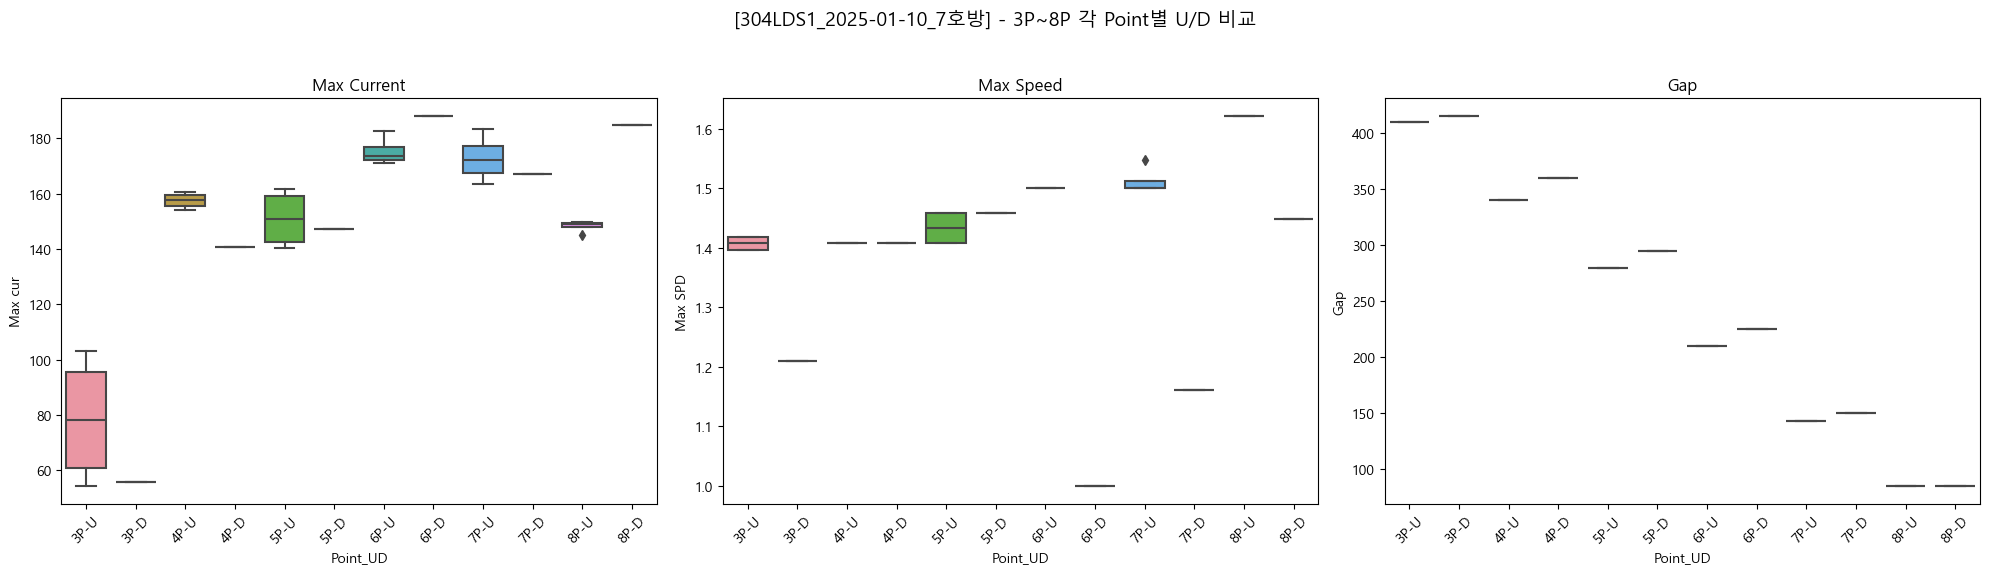

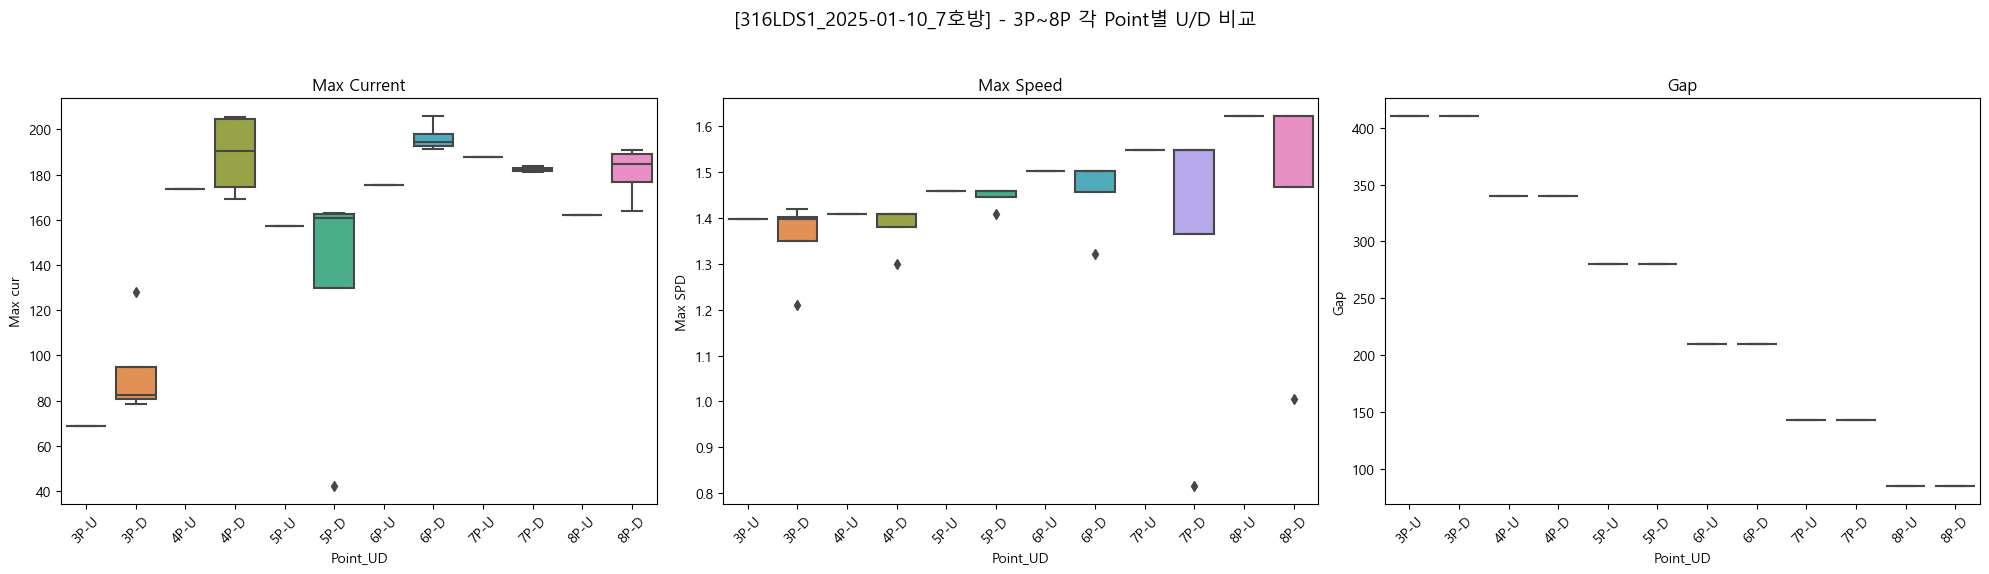

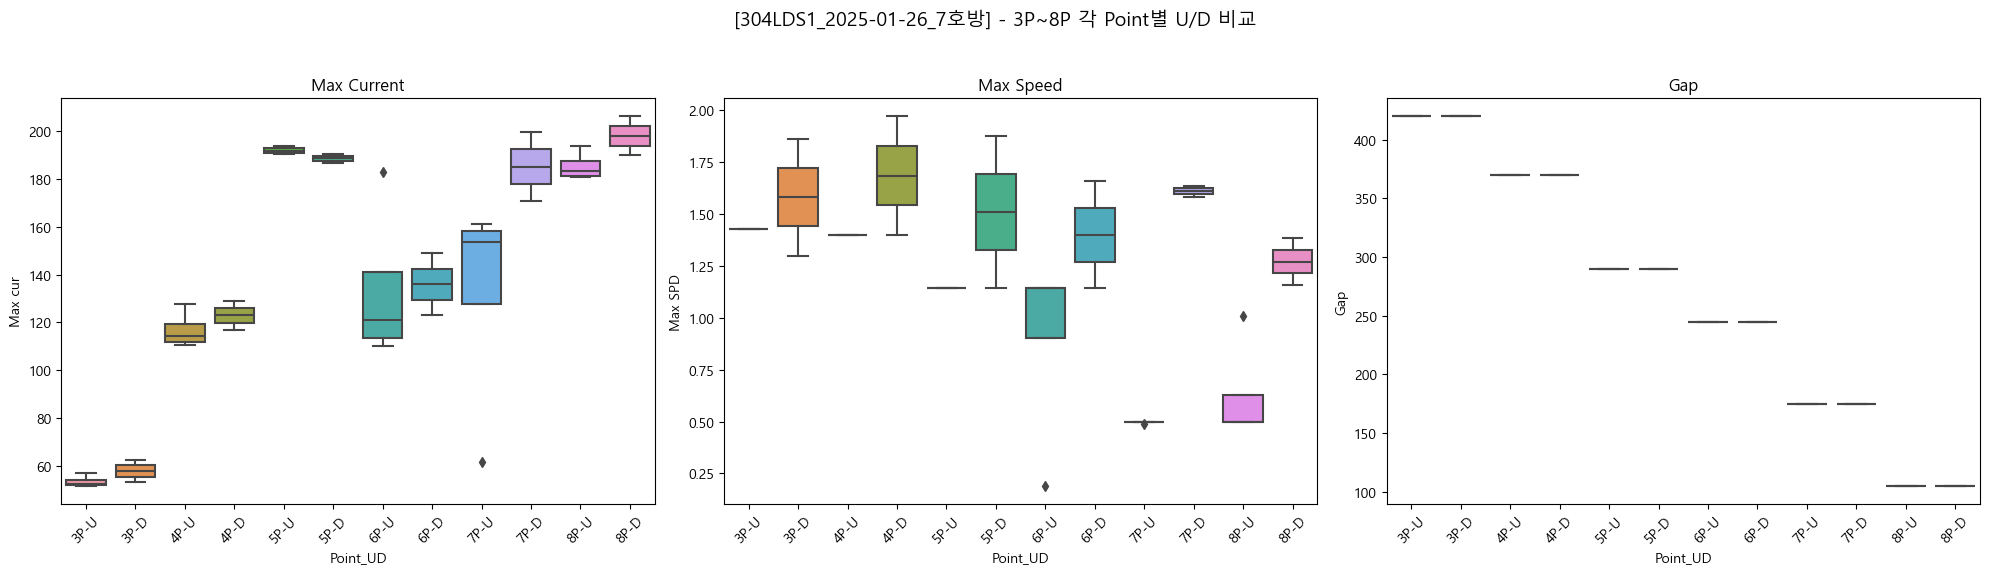

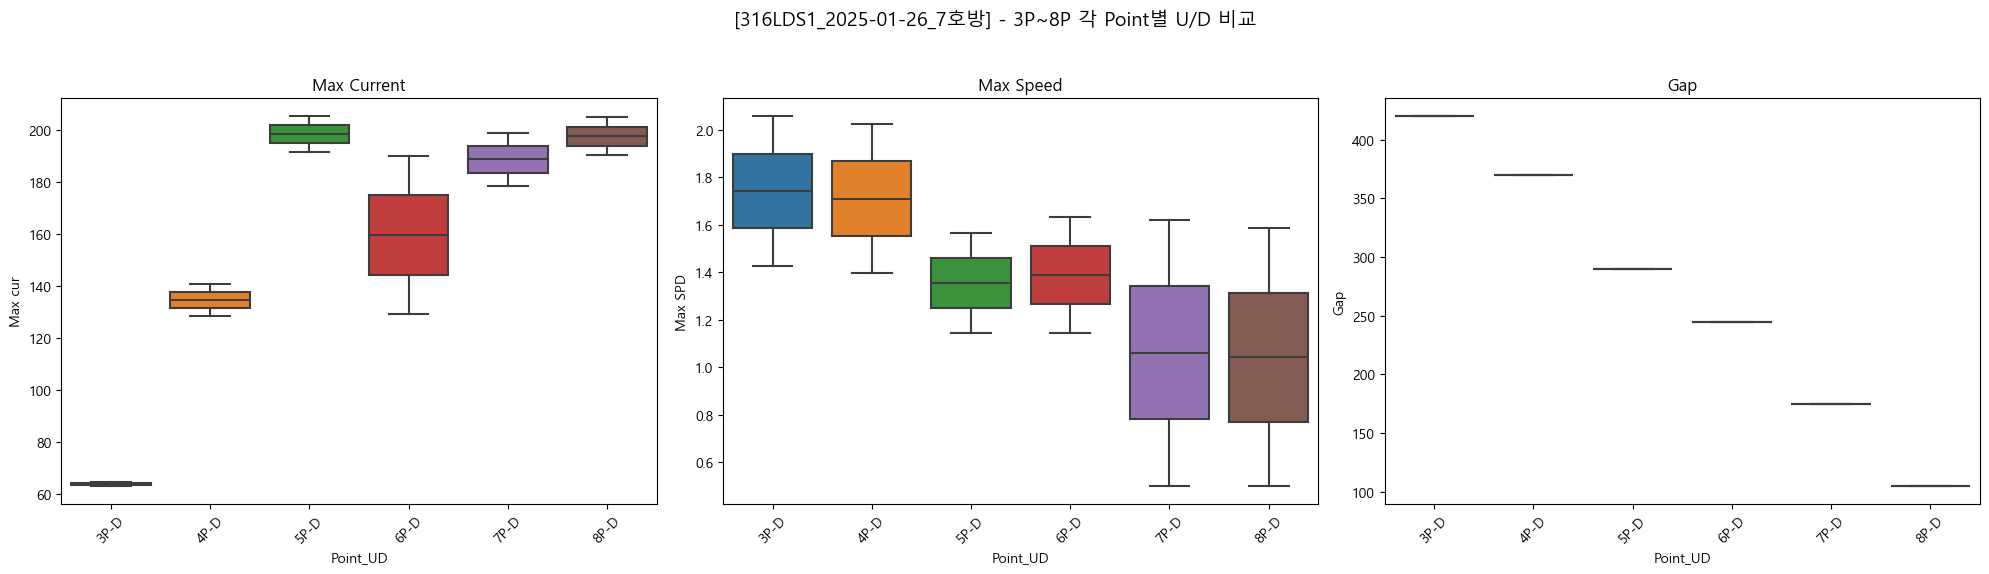

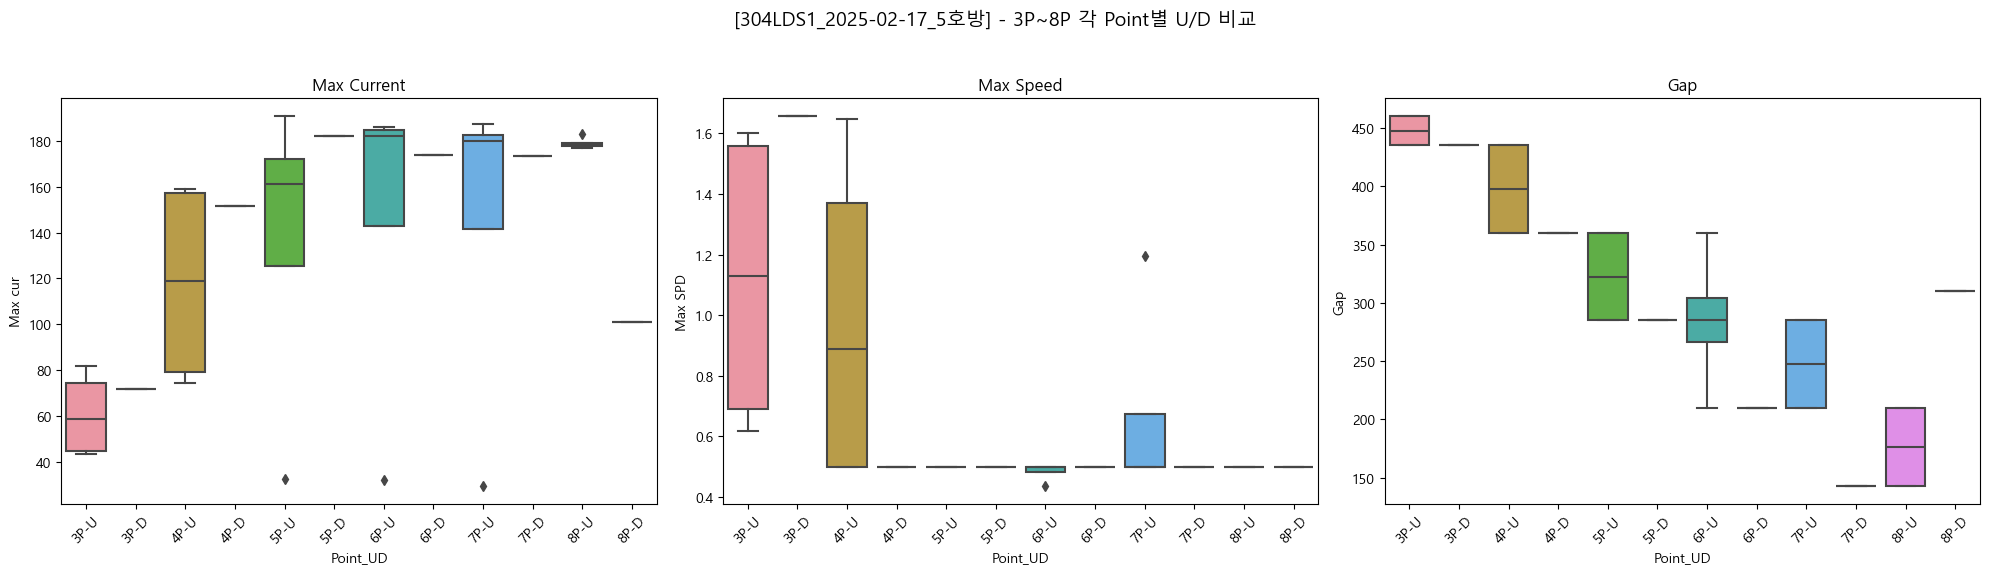

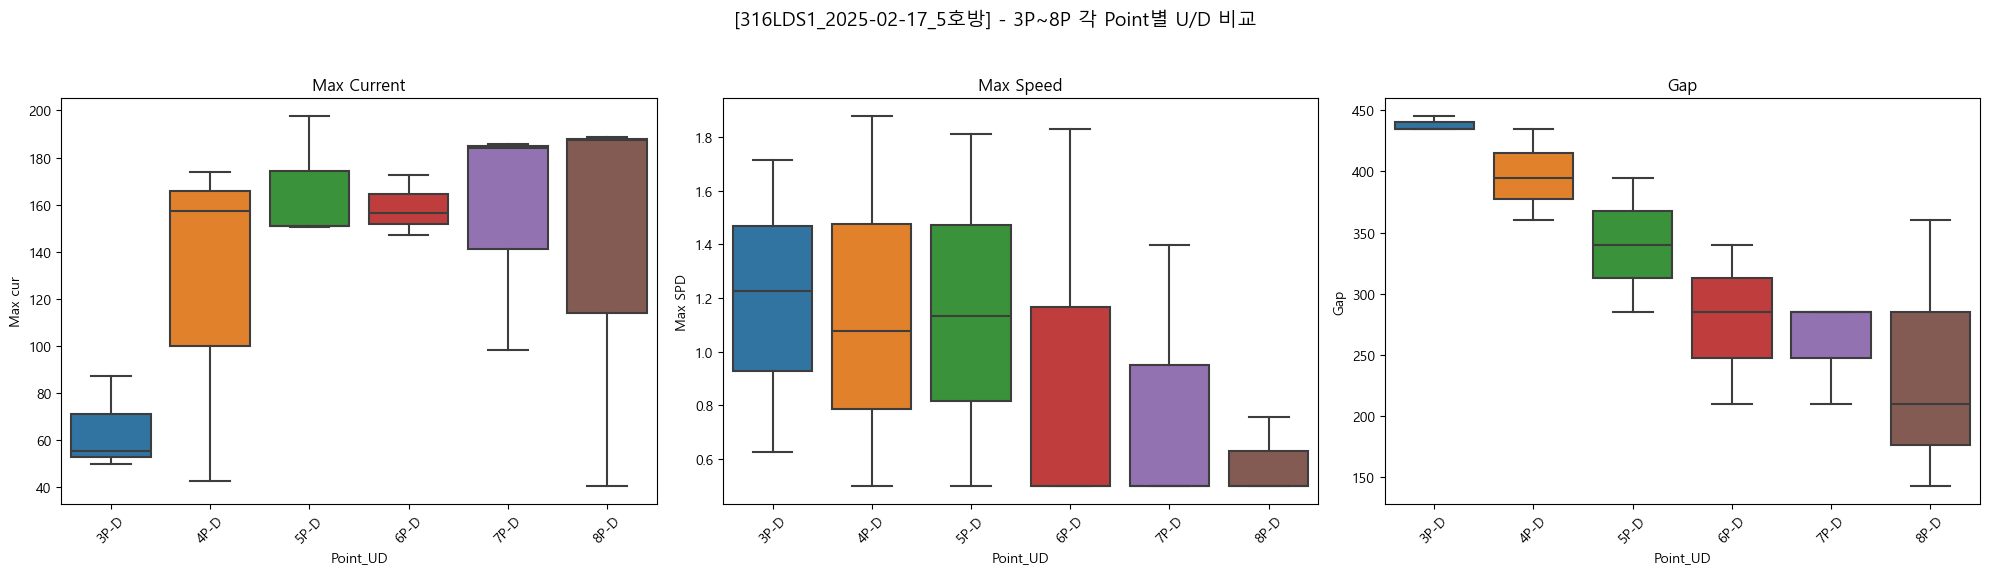

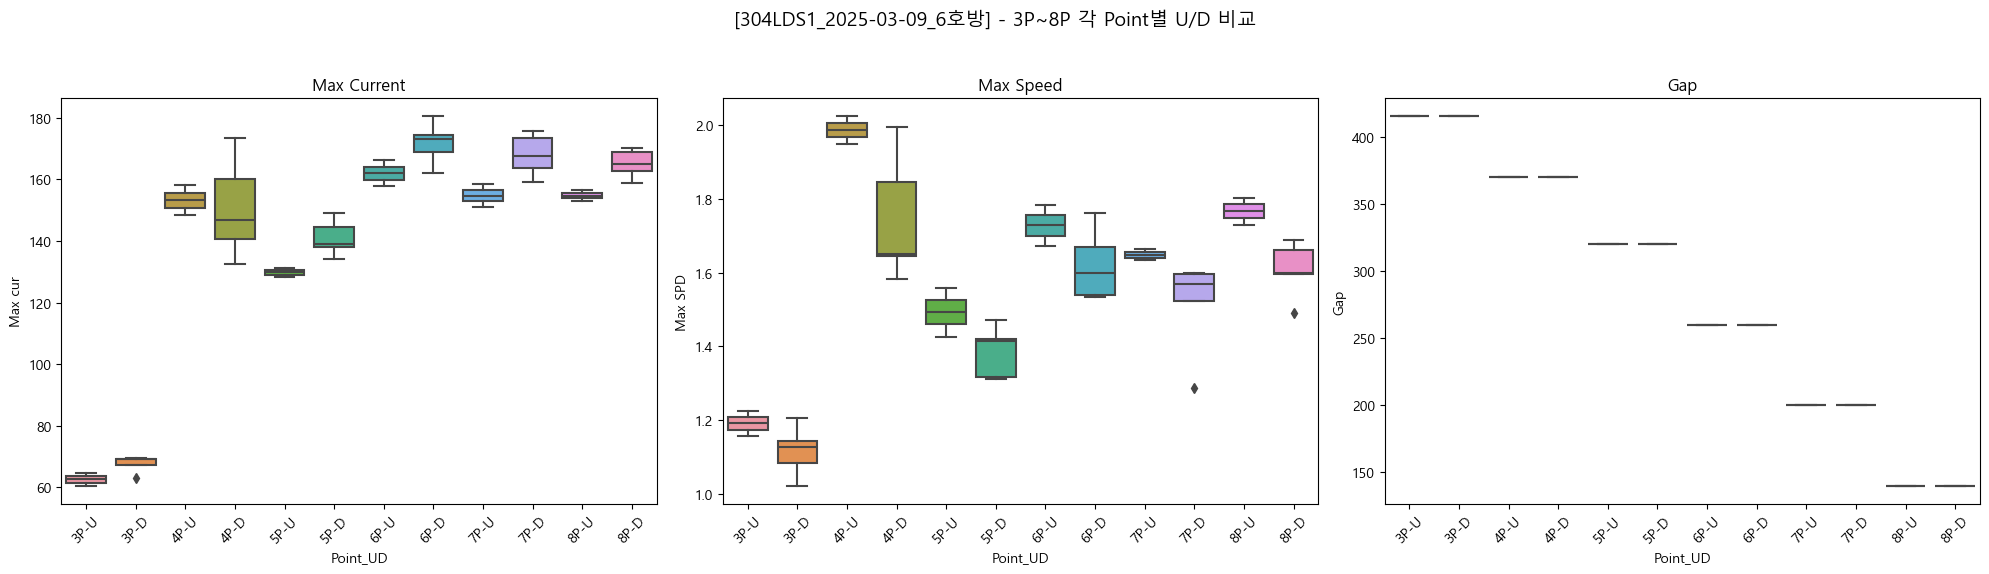

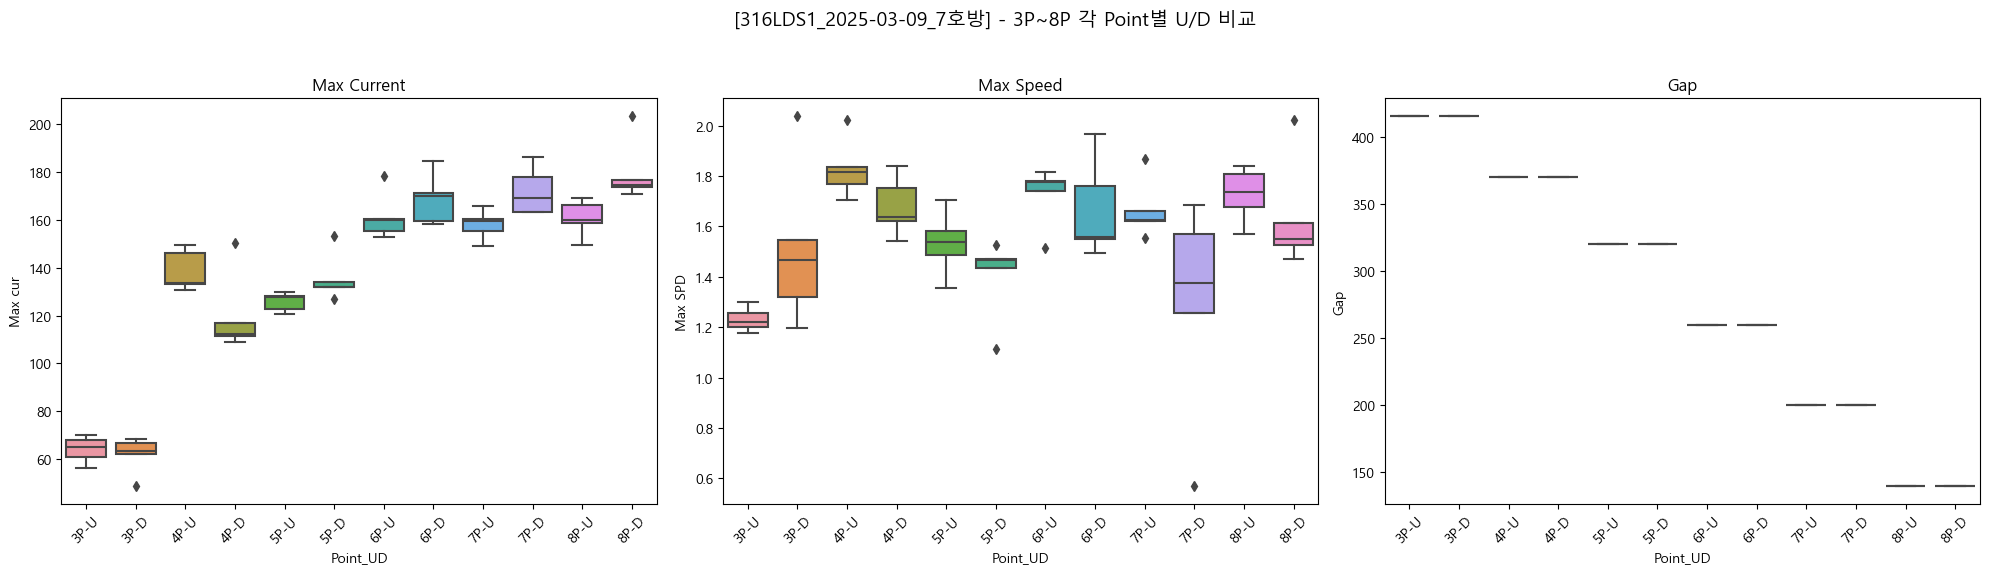

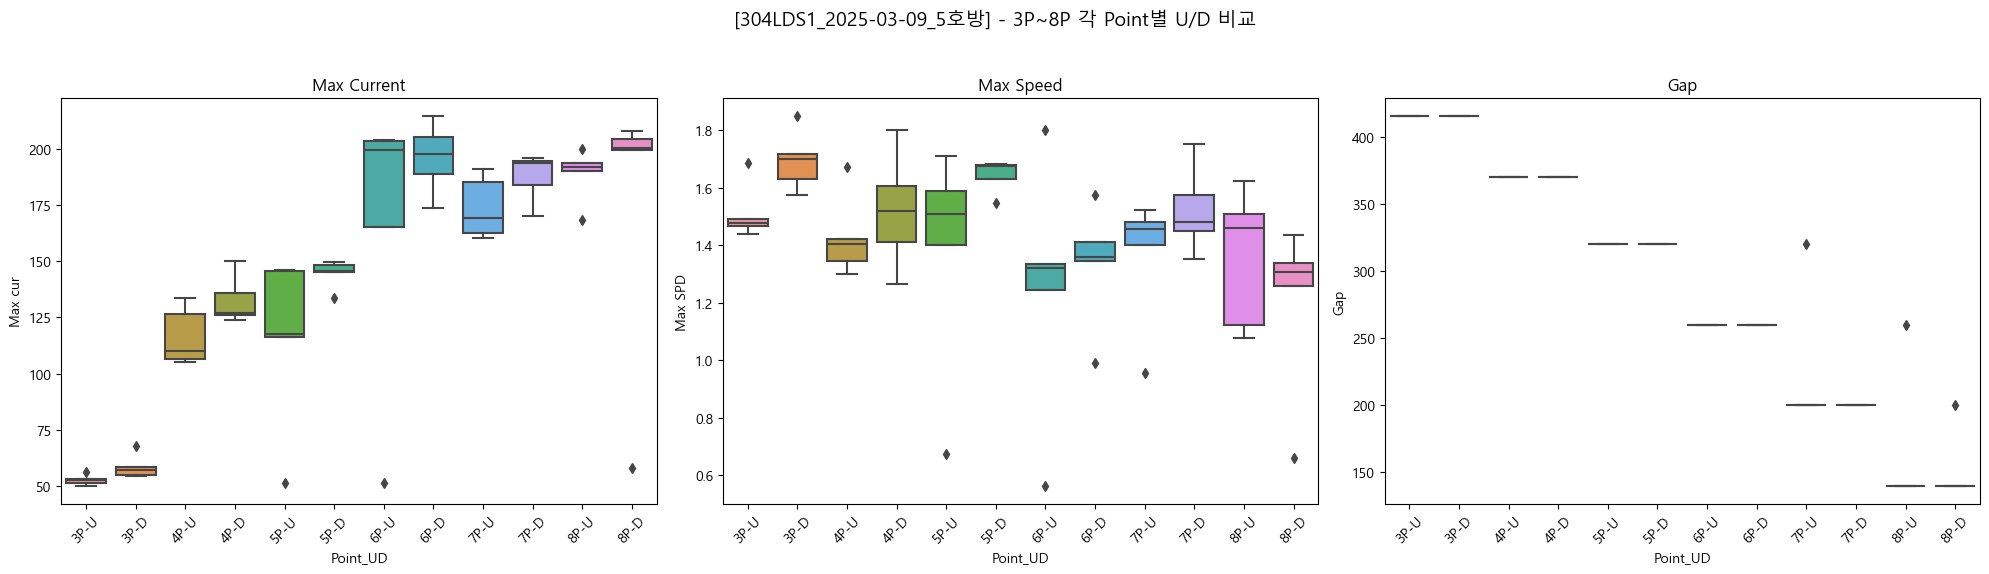

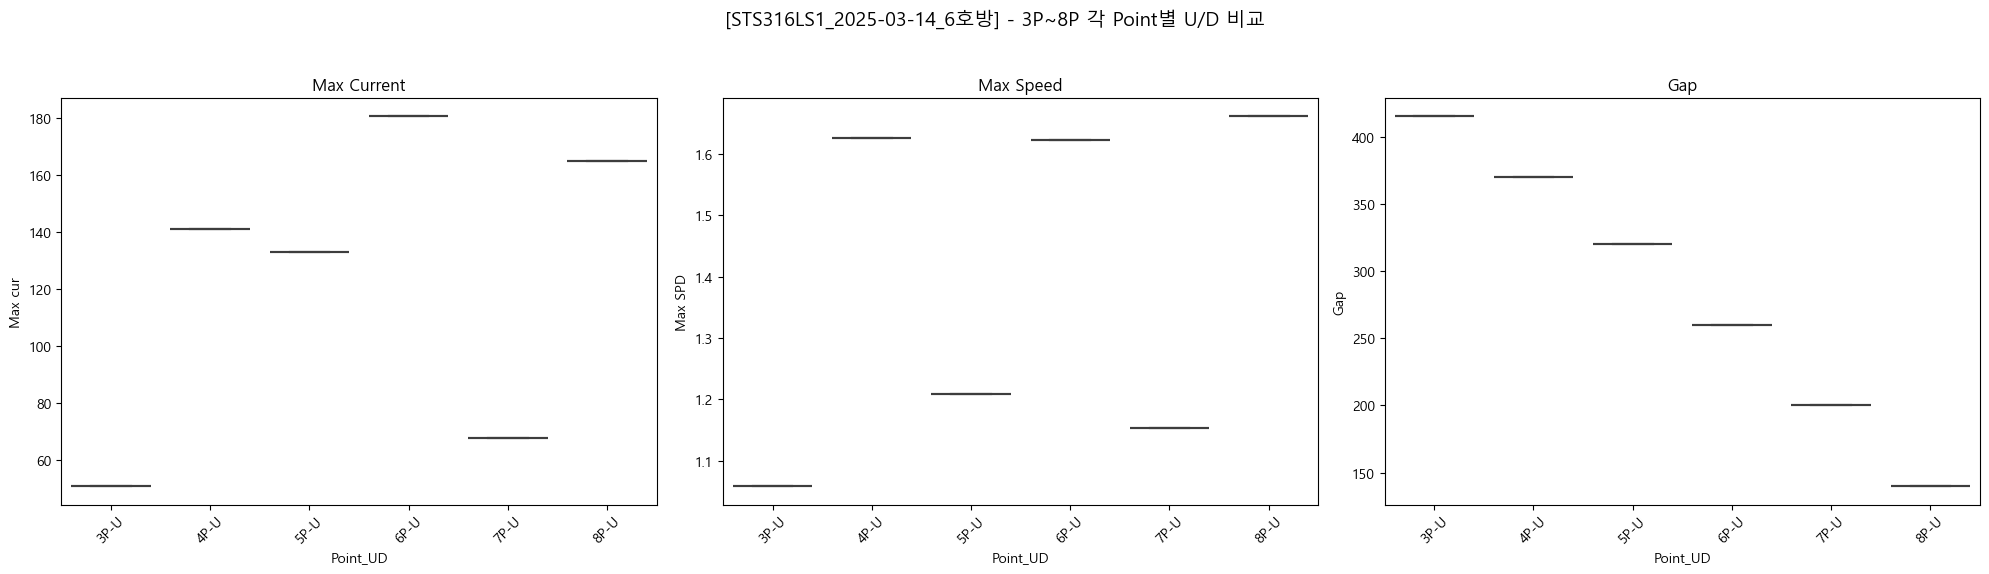

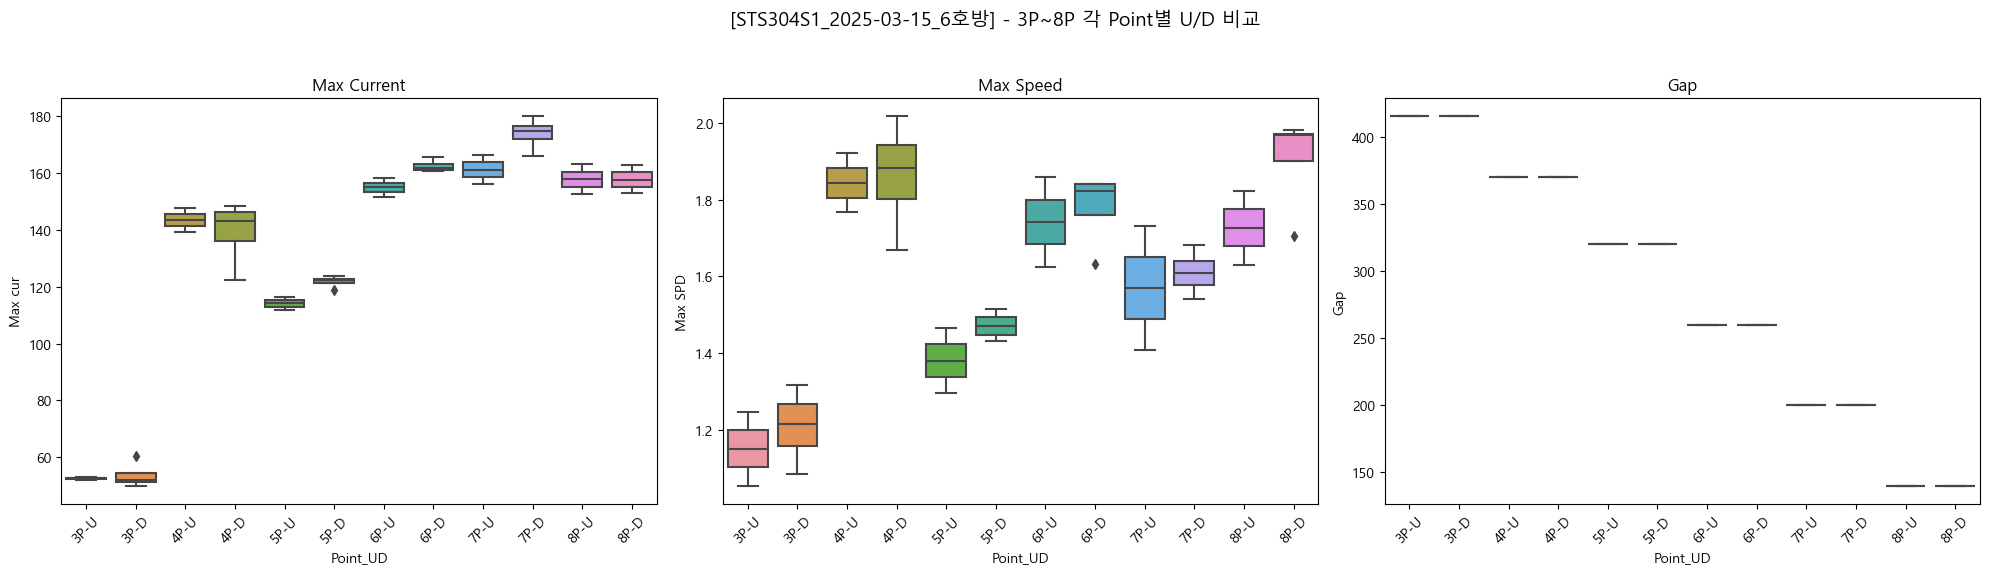

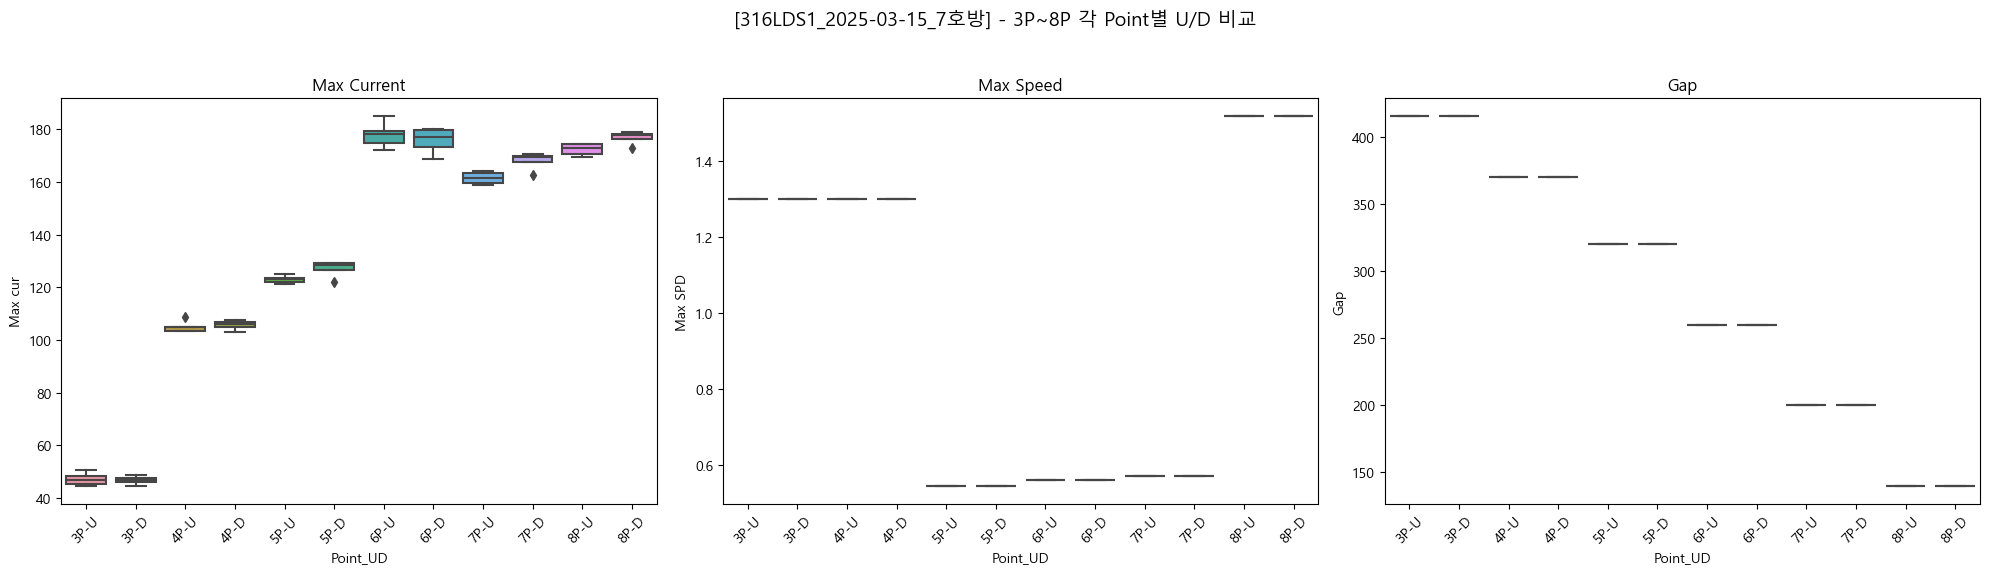

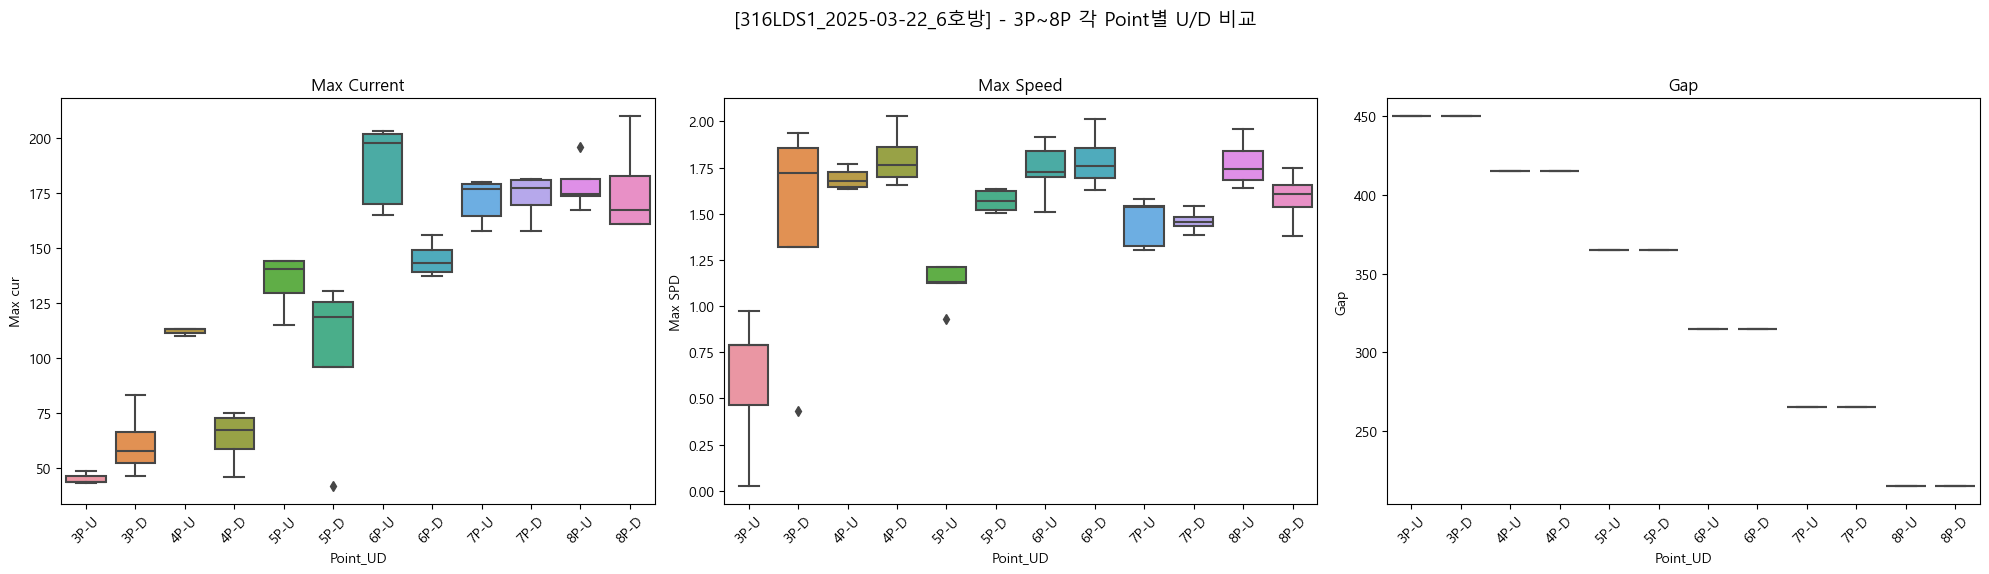

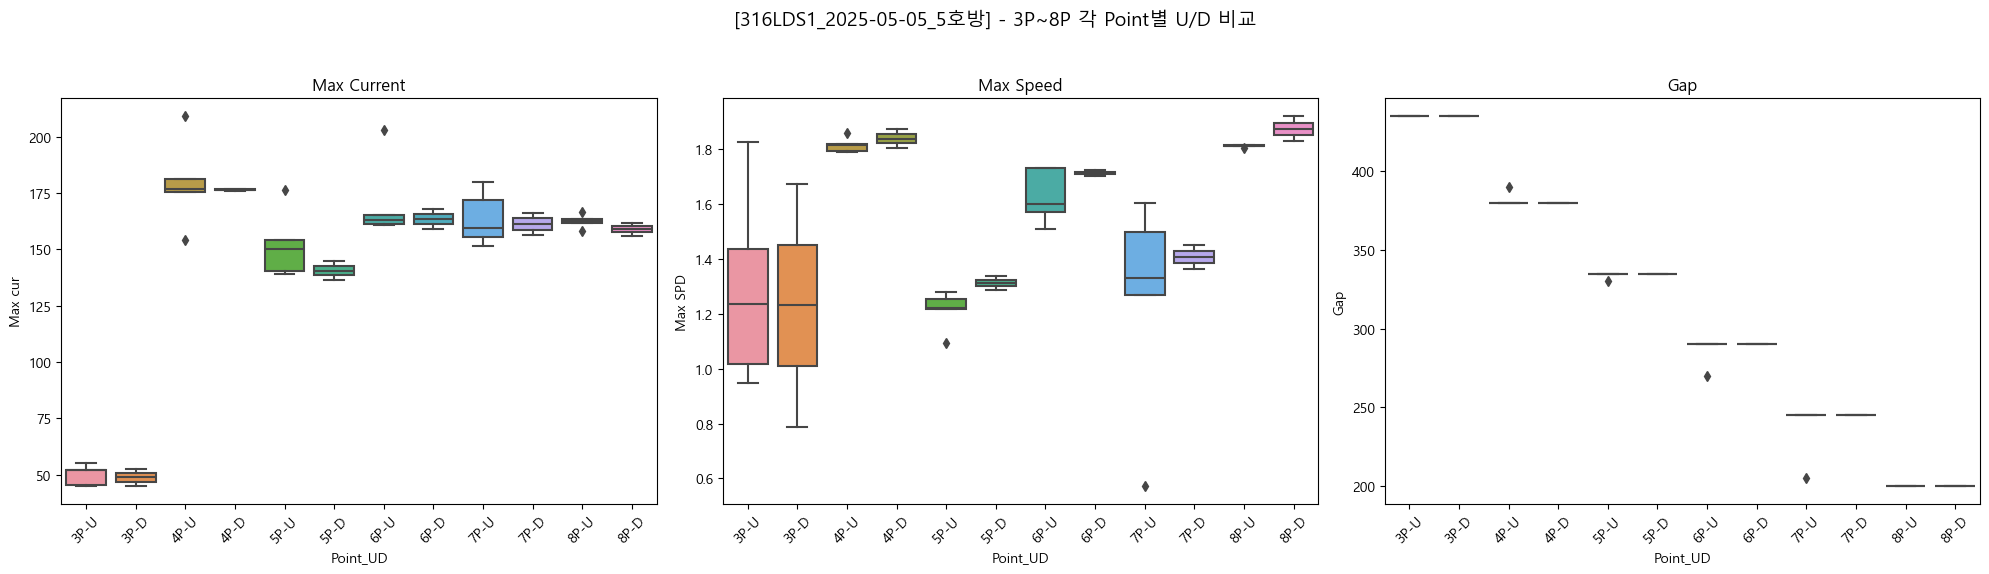

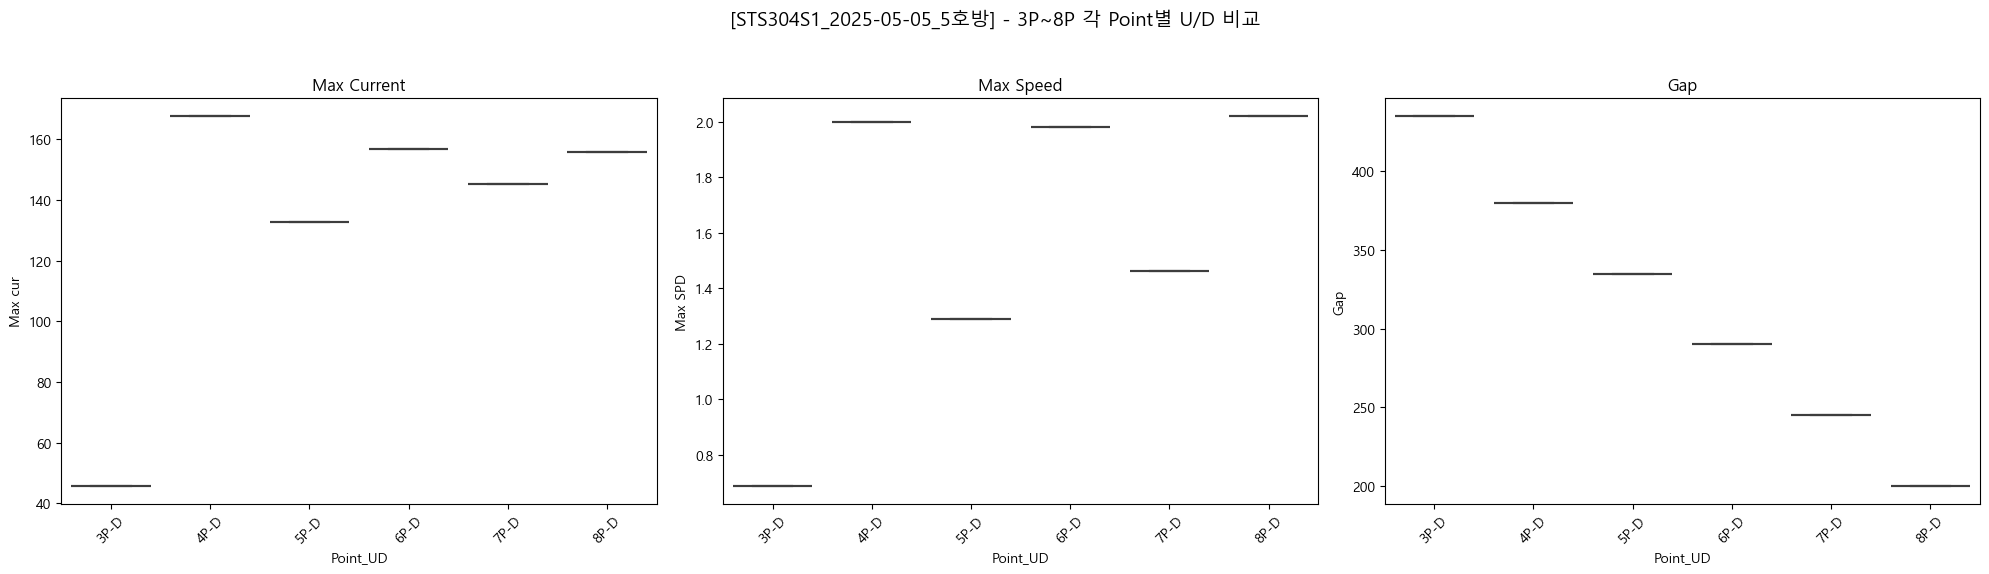

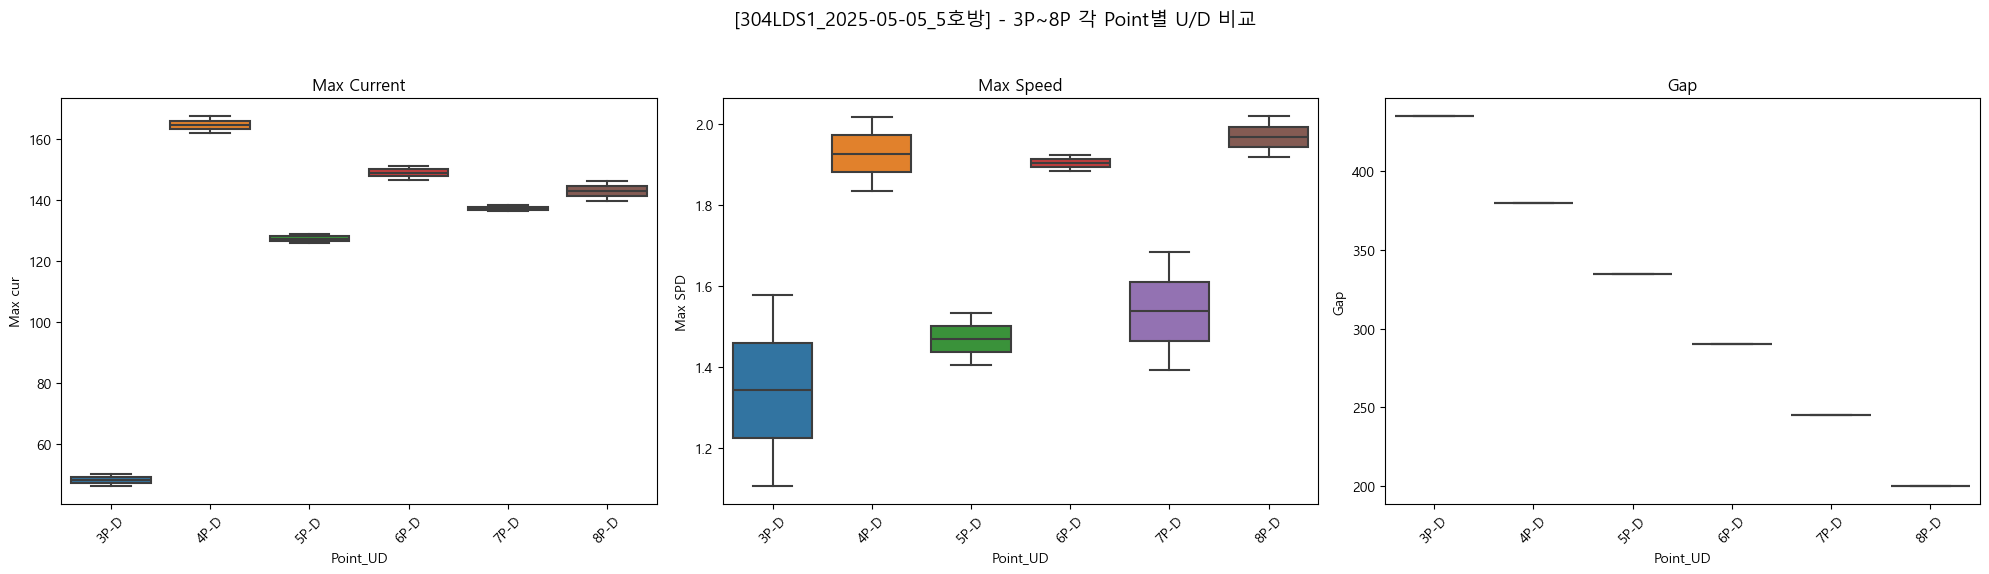

In [24]:
#가열호수 추가 코드
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 📌 한글 폰트 설정 (Windows 환경 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 📁 엑셀 파일 경로 설정
file_path = os.path.join("data1", "250609_Data_form.xlsx")  # 파일명은 실제와 맞게 수정하세요

# 📥 데이터 불러오기
df = pd.read_excel(file_path)

# 🔧 구분 열 생성: 사내강종 + 시작일 + 가열호수
df['구분'] = (
    df['사내강종'].astype(str) + "_" +
    df['시작일'].astype(str) + "_" +
    df['가열호수'].astype(str)
)

# 🔄 3P~8P 데이터를 long-form으로 변환
melted = pd.DataFrame()
for p in range(3, 9):
    temp = df[['구분', 'UD', f'Max cur_{p}P', f'Max SPD_{p}P', f'Gap_{p}P']].copy()
    temp = temp.rename(columns={
        f'Max cur_{p}P': 'Max cur',
        f'Max SPD_{p}P': 'Max SPD',
        f'Gap_{p}P': 'Gap'
    })
    temp['Point'] = f'{p}P'
    temp['Point_UD'] = f'{p}P-' + temp['UD']
    melted = pd.concat([melted, temp], ignore_index=True)

# 🎯 구분별로 3개의 Boxplot 출력 (x축: Point_UD)
for key in melted['구분'].unique():
    subset = melted[melted['구분'] == key]

    # 전체 데이터가 비어있으면 skip
    if subset[['Max cur', 'Max SPD', 'Gap']].dropna(how='all').empty:
        continue

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
    fig.suptitle(f"[{key}] - 3P~8P 각 Point별 U/D 비교", fontsize=14)

    # Max cur boxplot
    if not subset['Max cur'].dropna().empty:
        sns.boxplot(data=subset, x='Point_UD', y='Max cur', ax=axes[0])
        axes[0].set_title('Max Current')
        axes[0].set_ylabel('Max cur')
        axes[0].tick_params(axis='x', rotation=45)

    # Max SPD boxplot
    if not subset['Max SPD'].dropna().empty:
        sns.boxplot(data=subset, x='Point_UD', y='Max SPD', ax=axes[1])
        axes[1].set_title('Max Speed')
        axes[1].set_ylabel('Max SPD')
        axes[1].tick_params(axis='x', rotation=45)

    # Gap boxplot
    if not subset['Gap'].dropna().empty:
        sns.boxplot(data=subset, x='Point_UD', y='Gap', ax=axes[2])
        axes[2].set_title('Gap')
        axes[2].set_ylabel('Gap')
        axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [2]:
import pandas as pd
import os
from glob import glob

# 📁 분석할 텍스트 파일이 있는 폴더 경로
input_folder = r'C:\python_study\01.엑셀자동화기초\data2'
txt_files = glob(os.path.join(input_folder, '*.txt'))

for file_path in txt_files:
    try:
        file_name = os.path.basename(file_path)
        name_without_ext = os.path.splitext(file_name)[0]

        # 1️⃣ 파일 불러오기
        df = pd.read_csv(file_path, sep=';', parse_dates=['Time'], dayfirst=True)

        # 2️⃣ 태그 이름 설정
        CURR_COL = '[110:2]'      # 전류
        SPD_COL = '[110:10]'      # 속도
        GAP_COL = '[112:28]'      # gap
        PASS_COL = '[112:29]'     # pass 번호
        DOOR_COL = '[6.0]'        # DOOR #1 UP SIGNAL

        # 3️⃣ Pass 번호 전처리
        df = df.dropna(subset=[PASS_COL])
        df['Pass_no'] = df[PASS_COL].astype(int)

        # DOOR 상승 edge 추출 (0 → 1)
        df['DOOR_EDGE'] = (df[DOOR_COL] == 1) & (df[DOOR_COL].shift(fill_value=0) == 0)
        door_up_times = df.loc[df['DOOR_EDGE'], 'Time'].reset_index(drop=True)

        # 4️⃣ Pass 그룹핑 (같은 pass 번호 구간별 구분)
        df['Group'] = (df['Pass_no'] != df['Pass_no'].shift()).cumsum()

        # 5️⃣ ✅ 분석 1: 각 Pass 구간 내 최대 전류 + DOOR 기준 시간차
        result1 = []
        for _, g in df.groupby('Group'):
            pass_no = g['Pass_no'].iloc[0]
            max_idx = g[CURR_COL].idxmax()
            row = df.loc[max_idx]
            max_time = row['Time']
            prev_door = door_up_times[door_up_times <= max_time]
            door_time = prev_door.iloc[-1] if not prev_door.empty else pd.NaT
            delta_t = (max_time - door_time).total_seconds() if pd.notna(door_time) else None
            result1.append({
                'Pass_no': pass_no,
                '시간_최대전류': max_time,
                '최대전류': row[CURR_COL],
                '속도': abs(row[SPD_COL]),
                'gap': row[GAP_COL],
                'DOOR_시작시각': door_time,
                'DOOR→최대전류_시간차(초)': delta_t
            })
        result_df1 = pd.DataFrame(result1)

        # 6️⃣ ✅ 분석 2: Pass 전환 종료시점 기준 DOOR와 시간차 계산
        pass_door_results = []
        df['Pass_shift'] = df['Pass_no'].shift()
        df['Pass_change'] = (df['Pass_no'] != df['Pass_shift'])
        pass_transitions = df[df['Pass_change']].reset_index(drop=True)

        for i in range(len(pass_transitions) - 1):
            end_time = pass_transitions.loc[i + 1, 'Time']
            pass_no = pass_transitions.loc[i, 'Pass_no']
            nearest_door = door_up_times[door_up_times <= end_time]
            if not nearest_door.empty:
                door_time = nearest_door.iloc[-1]
                time_diff = (end_time - door_time).total_seconds()
                pass_door_results.append({
                    'Pass_no': pass_no,
                    'Pass_종료시각': end_time,
                    'DOOR_상승시각': door_time,
                    'DOOR→Pass종료_시간차(초)': time_diff
                })
        pass_door_df = pd.DataFrame(pass_door_results)

        # 7️⃣ Excel 파일 저장 (원본 .txt와 같은 경로)
        output_path = os.path.join(os.path.dirname(file_path), f"{name_without_ext}.xlsx")
        with pd.ExcelWriter(output_path) as writer:
            result_df1.to_excel(writer, sheet_name='최대전류_정보', index=False)
            pass_door_df.to_excel(writer, sheet_name='DOOR→각Pass종료', index=False)

        print(f"✅ 저장 완료: {output_path}")

    except Exception as e:
        print(f"❌ 오류 발생: {file_path} → {e}")

✅ 저장 완료: C:\python_study\01.엑셀자동화기초\data2\250309.xlsx
✅ 저장 완료: C:\python_study\01.엑셀자동화기초\data2\250315.xlsx


In [6]:
import pandas as pd
import os
from glob import glob

# 📁 분석할 텍스트 파일이 있는 폴더 경로
input_folder = r'C:\python_study\01.엑셀자동화기초\data2'
txt_files = glob(os.path.join(input_folder, '*.txt'))

for file_path in txt_files:
    try:
        file_name = os.path.basename(file_path)
        name_without_ext = os.path.splitext(file_name)[0]

        # 1️⃣ 파일 불러오기
        df = pd.read_csv(file_path, sep=';', parse_dates=['Time'], dayfirst=True)

        # 2️⃣ 태그 이름 설정
        CURR_COL = '[110:2]'      # 전류
        SPD_COL = '[110:10]'      # 속도
        GAP_COL = '[112:28]'      # gap
        PASS_COL = '[112:29]'     # pass 번호
        DOOR_COL = '[6.0]'        # DOOR #1 UP SIGNAL

        # 3️⃣ Pass 번호 전처리
        df = df.dropna(subset=[PASS_COL])
        df['Pass_no'] = df[PASS_COL].astype(int)

        # 4️⃣ DOOR 상승 edge 추출 (0 → 1)
        df['DOOR_EDGE'] = (df[DOOR_COL] == 1) & (df[DOOR_COL].shift(fill_value=0) == 0)

        # 5️⃣ 각 row별로 최근 DOOR 상승 시각을 할당 (forward fill)
        df['DOOR_LATEST'] = pd.NaT
        df.loc[df['DOOR_EDGE'], 'DOOR_LATEST'] = df.loc[df['DOOR_EDGE'], 'Time']
        df['DOOR_LATEST'] = df['DOOR_LATEST'].ffill()

        # 6️⃣ Pass 그룹핑 (같은 pass 번호 구간별 구분)
        df['Group'] = (df['Pass_no'] != df['Pass_no'].shift()).cumsum()

        # 7️⃣ ✅ 분석 1: 각 Pass 구간 내 최대 전류 + DOOR 기준 시간차
        result1 = []
        for _, g in df.groupby('Group'):
            pass_no = g['Pass_no'].iloc[0]
            max_idx = g[CURR_COL].idxmax()
            row = df.loc[max_idx]
            max_time = row['Time']
            door_time = row['DOOR_LATEST']
            delta_t = (max_time - door_time).total_seconds() if pd.notna(door_time) else None
            result1.append({
                'Pass_no': pass_no,
                '시간_최대전류': max_time,
                '최대전류': row[CURR_COL],
                '속도': abs(row[SPD_COL]),
                'gap': row[GAP_COL],
                'DOOR_시작시각': door_time,
                'DOOR→최대전류_시간차(초)': delta_t
            })
        result_df1 = pd.DataFrame(result1)

        # 8️⃣ ✅ 분석 2: Pass 전환 종료시점 기준 DOOR와 시간차 계산
        pass_door_results = []
        df['Pass_shift'] = df['Pass_no'].shift()
        df['Pass_change'] = (df['Pass_no'] != df['Pass_shift'])
        pass_transitions = df[df['Pass_change']].reset_index(drop=True)

        for i in range(len(pass_transitions) - 1):
            end_time = pass_transitions.loc[i + 1, 'Time']
            pass_no = pass_transitions.loc[i, 'Pass_no']
            # 해당 end_time까지 가장 최근의 DOOR 상승 시각
            door_time = df.loc[df['Time'] <= end_time, 'DOOR_LATEST'].iloc[-1]
            time_diff = (end_time - door_time).total_seconds() if pd.notna(door_time) else None
            pass_door_results.append({
                'Pass_no': pass_no,
                'Pass_종료시각': end_time,
                'DOOR_상승시각': door_time,
                'DOOR→Pass종료_시간차(초)': time_diff
            })
        pass_door_df = pd.DataFrame(pass_door_results)

        # 9️⃣ Excel 파일 저장 (원본 .txt와 같은 경로)
        output_path = os.path.join(os.path.dirname(file_path), f"{name_without_ext}.xlsx")
        with pd.ExcelWriter(output_path) as writer:
            result_df1.to_excel(writer, sheet_name='최대전류_정보', index=False)
            pass_door_df.to_excel(writer, sheet_name='DOOR→각Pass종료', index=False)

        print(f"✅ 저장 완료: {output_path}")

    except Exception as e:
        print(f"❌ 오류 발생: {file_path} → {e}")


✅ 저장 완료: C:\python_study\01.엑셀자동화기초\data2\250309.xlsx
✅ 저장 완료: C:\python_study\01.엑셀자동화기초\data2\250315.xlsx
